# Speech Emotion Recognition — Log-Mel + BiLSTM Pipeline (v2)

In [10]:
import os, re, pickle, random

import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.utils.class_weight import compute_class_weight

# ── Paths ──────────────────────────────────────────────────────────────────
RAVDESS_PATH = "../../data/ravdess"
SAVEE_PATH   = "../../data/savee"

# ── Emotion mappings ───────────────────────────────────────────────────────
emotion_to_label = {
    "neutral": 0, "calm": 1, "happy": 2, "sad": 3,
    "angry": 4, "fear": 5, "disgust": 6, "surprise": 7
}
ravdess_code_to_emotion = {
    "01": "neutral", "02": "calm",    "03": "happy",
    "04": "sad",     "05": "angry",   "06": "fear",
    "07": "disgust", "08": "surprise"
}
savee_code_to_emotion = {
    "a": "angry", "d": "disgust", "f": "fear",
    "h": "happy", "n": "neutral", "sa": "sad", "su": "surprise"
}

# ── Audio / Feature params ─────────────────────────────────────────────────
SAMPLE_RATE = 16000
N_MELS      = 128
N_FFT       = 1024
HOP_LENGTH  = 512
MAX_STEPS   = 128   # ~4 s @ 16 kHz / 512 hop

# ── Training params ────────────────────────────────────────────────────────
BATCH_SIZE  = 64
EPOCHS      = 200
LR          = 1e-3   # higher start LR — scheduler will reduce it
PATIENCE    = 15

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")
print(f"MAX_STEPS = {MAX_STEPS}  (~{MAX_STEPS * HOP_LENGTH / SAMPLE_RATE:.1f} s)")

Device : cuda
MAX_STEPS = 128  (~4.1 s)


## 1 · Load Metadata (RAVDESS + SAVEE)

In [11]:
records = []
for actor in os.listdir(RAVDESS_PATH):
    for fn in os.listdir(f"{RAVDESS_PATH}/{actor}"):
        if not fn.endswith(".wav"):
            continue
        parts   = fn.replace(".wav", "").split("-")
        emotion = ravdess_code_to_emotion[parts[2]]
        records.append({"path": f"{RAVDESS_PATH}/{actor}/{fn}",
                         "speaker": parts[6], "emotion": emotion,
                         "label": emotion_to_label[emotion], "dataset": "RAVDESS"})
ravdess_df = pd.DataFrame(records)
print(f"RAVDESS : {len(ravdess_df)} samples")
print(ravdess_df["emotion"].value_counts())

RAVDESS : 1440 samples
emotion
calm        192
happy       192
sad         192
angry       192
fear        192
disgust     192
surprise    192
neutral      96
Name: count, dtype: int64


In [12]:
records = []
for fn in os.listdir(SAVEE_PATH):
    if not fn.lower().endswith(".wav"):
        continue
    speaker, ep = os.path.splitext(fn)[0].split("_")
    code        = re.match(r"[a-z]+", ep).group()  # type: ignore
    emotion     = savee_code_to_emotion[code]
    records.append({"path": f"{SAVEE_PATH}/{fn}",
                     "speaker": speaker, "emotion": emotion,
                     "label": emotion_to_label[emotion], "dataset": "SAVEE"})
savee_df = pd.DataFrame(records).sort_values("path").reset_index(drop=True)
print(f"SAVEE   : {len(savee_df)} samples")
print(savee_df["emotion"].value_counts())

SAVEE   : 480 samples
emotion
neutral     120
angry        60
disgust      60
fear         60
happy        60
sad          60
surprise     60
Name: count, dtype: int64


Combined: (1920, 5)


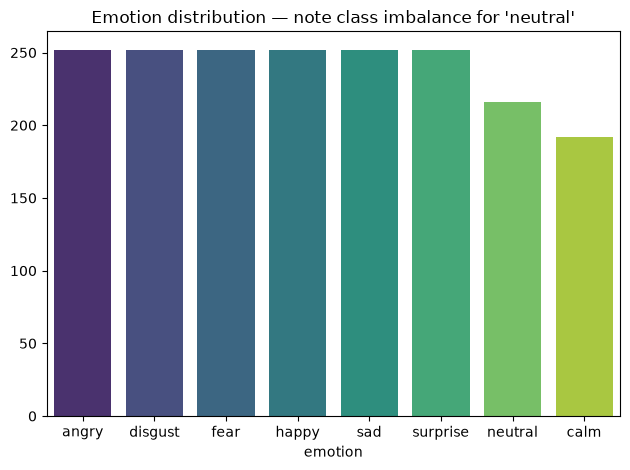

In [13]:
combined_df = pd.concat([savee_df, ravdess_df], ignore_index=True)
print(f"Combined: {combined_df.shape}")
os.makedirs("CSVs", exist_ok=True)
combined_df.to_csv("CSVs/combined_metadata.csv", index=False)

counts = combined_df["emotion"].value_counts()
sns.barplot(x=counts.index, y=counts.values, hue=counts.index,
            palette="viridis", legend=False)
plt.title("Emotion distribution — note class imbalance for 'neutral'")
plt.tight_layout(); plt.show()

## 2 · Extract Log-Mel Spectrograms

In [14]:
def extract_logmelspectrogram(audio_path):
    """Load audio → log-Mel spectrogram → (time_steps, N_MELS)"""
    audio, sr = librosa.load(audio_path, sr=SAMPLE_RATE)
    mel       = librosa.feature.melspectrogram(
        y=audio, sr=sr, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH
    )
    return librosa.power_to_db(mel, ref=np.max).T  # (T, N_MELS)


def pad_or_trim(spec, max_steps=MAX_STEPS):
    T = spec.shape[0]
    if T >= max_steps:
        return spec[:max_steps]
    return np.pad(spec, ((0, max_steps - T), (0, 0)), mode="constant")


logmelspec_data, logmelspec_labels = [], []
for _, row in tqdm(combined_df.iterrows(), total=len(combined_df),
                   desc="Extracting"):
    spec = pad_or_trim(extract_logmelspectrogram(row["path"]))
    logmelspec_data.append(spec)
    logmelspec_labels.append(row["label"])

print(f"\n✓ {len(logmelspec_data)} samples | shape: {logmelspec_data[0].shape}")
os.makedirs("features", exist_ok=True)
with open("features/data.pkl", "wb") as f:
    pickle.dump({"logmelspec_data": logmelspec_data,
                 "logmelspec_labels": np.array(logmelspec_labels),
                 "sample_rate": SAMPLE_RATE, "n_mel": N_MELS,
                 "max_steps": MAX_STEPS}, f)
print("✓ Saved → features/data.pkl")

Extracting: 100%|██████████| 1920/1920 [00:10<00:00, 187.16it/s]



✓ 1920 samples | shape: (128, 128)
✓ Saved → features/data.pkl


## 3 · Train / Val / Test Split  (80 / 10 / 10)

In [15]:
raw_data   = logmelspec_data
raw_labels = np.array(logmelspec_labels)

X_tv, X_test, y_tv, y_test = train_test_split(
    raw_data, raw_labels, test_size=0.1, random_state=42, stratify=raw_labels
)
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv, test_size=0.111, random_state=42, stratify=y_tv
)
print(f"Train: {len(X_train)}  |  Val: {len(X_val)}  |  Test: {len(X_test)}")

Train: 1536  |  Val: 192  |  Test: 192


## 4 · Dataset with SpecAugment + DataLoader

In [16]:
class AudioDataset(Dataset):
    """Log-mel dataset with optional SpecAugment augmentation.

    SpecAugment (Park et al., 2019):
      - Time masking  : randomly zero out up to `T_mask` consecutive time frames
      - Freq masking  : randomly zero out up to `F_mask` consecutive mel bands
    Applied only during training (augment=True).
    """
    def __init__(self, data_list, label_list, augment=False,
                 T_mask=20, F_mask=20, n_time_masks=2, n_freq_masks=2):
        self.data          = data_list
        self.labels        = label_list
        self.augment       = augment
        self.T_mask        = T_mask
        self.F_mask        = F_mask
        self.n_time_masks  = n_time_masks
        self.n_freq_masks  = n_freq_masks

    def __len__(self):
        return len(self.data)

    def _spec_augment(self, spec):
        spec = spec.copy()
        T, F = spec.shape
        # Time masking
        for _ in range(self.n_time_masks):
            t  = random.randint(0, self.T_mask)
            t0 = random.randint(0, max(T - t, 0))
            spec[t0:t0 + t, :] = 0.0
        # Frequency masking
        for _ in range(self.n_freq_masks):
            f  = random.randint(0, self.F_mask)
            f0 = random.randint(0, max(F - f, 0))
            spec[:, f0:f0 + f] = 0.0
        return spec

    def __getitem__(self, idx):
        spec  = self.data[idx].copy()
        # Normalise log-dB [-80, 0] → [0, 1]
        spec  = np.clip((spec + 80.0) / 80.0, 0.0, 1.0)
        if self.augment:
            spec = self._spec_augment(spec)
        return (torch.FloatTensor(spec),
                torch.tensor(self.labels[idx], dtype=torch.long))


train_loader = DataLoader(
    AudioDataset(X_train, y_train, augment=True),
    batch_size=BATCH_SIZE, shuffle=True,  num_workers=0
)
val_loader   = DataLoader(
    AudioDataset(X_val,   y_val,   augment=False),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=0
)
test_loader  = DataLoader(
    AudioDataset(X_test,  y_test,  augment=False),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=0
)
print("✓ DataLoaders ready  (SpecAugment active on train set)")

✓ DataLoaders ready  (SpecAugment active on train set)


## 5 · Class-Weighted Loss

In [17]:
classes       = np.unique(y_train)
class_weights = compute_class_weight(
    class_weight="balanced", classes=classes, y=y_train
)
weight_tensor = torch.FloatTensor(class_weights).to(device)
print("Class weights:")
label_names = [k for k, v in sorted(emotion_to_label.items(), key=lambda x: x[1])]
for i, (name, w) in enumerate(zip(label_names, class_weights)):
    print(f"  [{i}] {name:10s}  weight={w:.4f}")

Class weights:
  [0] neutral     weight=1.1163
  [1] calm        weight=1.2468
  [2] happy       weight=0.9505
  [3] sad         weight=0.9505
  [4] angry       weight=0.9552
  [5] fear        weight=0.9505
  [6] disgust     weight=0.9505
  [7] surprise    weight=0.9552


## 6 · BiLSTM Model with Attention Pooling

In [18]:
class AttentionPool(nn.Module):
    """Learnable soft-attention over time steps — collapses (B, T, H) → (B, H).
    Better than taking only the last time step because all frames contribute.
    """
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim, 1)

    def forward(self, x):                    # x: (B, T, H)
        weights = torch.softmax(self.attn(x), dim=1)  # (B, T, 1)
        return (weights * x).sum(dim=1)      # (B, H)


class AudioLSTMClassifier(nn.Module):
    """2-layer BiLSTM + Attention pooling + BN + Dropout + FC.

    Input : (batch, MAX_STEPS, N_MELS)
    Output: (batch, num_classes)  raw logits for CrossEntropyLoss
    """
    def __init__(self, input_dim=N_MELS, hidden_size=128,
                 num_classes=8, dropout_prob=0.4):
        super().__init__()
        self.lstm    = nn.LSTM(input_size=input_dim, hidden_size=hidden_size,
                               num_layers=2, batch_first=True,
                               bidirectional=True, dropout=0.3)
        self.pool    = AttentionPool(hidden_size * 2)
        self.bn      = nn.BatchNorm1d(hidden_size * 2)
        self.dropout = nn.Dropout(p=dropout_prob)
        self.fc      = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x):
        out, _ = self.lstm(x)       # (B, T, H*2)
        out    = self.pool(out)     # (B, H*2)  ← attention over all frames
        out    = self.bn(out)
        out    = self.dropout(out)
        return self.fc(out)


num_classes = len(np.unique(raw_labels))
model       = AudioLSTMClassifier(num_classes=num_classes).to(device)
criterion   = nn.CrossEntropyLoss(weight=weight_tensor)  # class-weighted
optimizer   = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler   = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=5,
)

print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f"\n✓ Model ready | params={total_params:,} | classes={num_classes}")

AudioLSTMClassifier(
  (lstm): LSTM(128, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (pool): AttentionPool(
    (attn): Linear(in_features=256, out_features=1, bias=True)
  )
  (bn): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout): Dropout(p=0.4, inplace=False)
  (fc): Linear(in_features=256, out_features=8, bias=True)
)

✓ Model ready | params=662,281 | classes=8


## 7 · Training with Early Stopping + LR Scheduler

In [19]:
best_val_loss    = float("inf")
patience_counter = 0
best_model_path  = "best_audio_lstm_model.pth"

history = {k: [] for k in
           ["train_loss", "train_acc", "train_f1",
            "val_loss",   "val_acc",   "val_f1",  "lr"]}

for epoch in range(EPOCHS):
    # ── Train ──────────────────────────────────────────────────────────────
    model.train()
    t_loss, t_preds, t_targets = 0.0, [], []
    for X, y in train_loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(X)
        loss   = criterion(logits, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        t_loss += loss.item() * X.size(0)
        t_preds.extend(logits.argmax(1).cpu().numpy())
        t_targets.extend(y.cpu().numpy())

    ep_t_loss = t_loss / len(train_loader.dataset)
    ep_t_acc  = accuracy_score(t_targets, t_preds)
    ep_t_f1   = f1_score(t_targets, t_preds, average="macro", zero_division=0)

    # ── Validate ───────────────────────────────────────────────────────────
    model.eval()
    v_loss, v_preds, v_targets = 0.0, [], []
    with torch.no_grad():
        for X, y in val_loader:
            X, y = X.to(device), y.to(device)
            logits = model(X)
            v_loss += criterion(logits, y).item() * X.size(0)
            v_preds.extend(logits.argmax(1).cpu().numpy())
            v_targets.extend(y.cpu().numpy())

    ep_v_loss = v_loss / len(val_loader.dataset)
    ep_v_acc  = accuracy_score(v_targets, v_preds)
    ep_v_f1   = f1_score(v_targets, v_preds, average="macro", zero_division=0)
    current_lr = optimizer.param_groups[0]["lr"]

    for k, v in [("train_loss", ep_t_loss), ("train_acc", ep_t_acc),
                 ("train_f1",   ep_t_f1),   ("val_loss",  ep_v_loss),
                 ("val_acc",    ep_v_acc),   ("val_f1",    ep_v_f1),
                 ("lr",         current_lr)]:
        history[k].append(v)

    print(f"Epoch [{epoch+1:03d}/{EPOCHS}]  lr={current_lr:.2e}  "
          f"train loss={ep_t_loss:.4f} acc={ep_t_acc*100:.1f}% f1={ep_t_f1:.4f}  |  "
          f"val loss={ep_v_loss:.4f} acc={ep_v_acc*100:.1f}% f1={ep_v_f1:.4f}")

    # ── Scheduler step ─────────────────────────────────────────────────────
    scheduler.step(ep_v_loss)

    # ── Early stopping / checkpoint ────────────────────────────────────────
    if ep_v_loss < best_val_loss:
        best_val_loss    = ep_v_loss
        patience_counter = 0
        torch.save(model.state_dict(), best_model_path)
        print(f"  🔥 Checkpoint saved (epoch {epoch+1})")
    else:
        patience_counter += 1
        print(f"  ⏳ No improvement — patience {patience_counter}/{PATIENCE}")
        if patience_counter >= PATIENCE:
            print(f"\n🛑 Early stopping at epoch {epoch+1}.")
            break

model.load_state_dict(torch.load(best_model_path))
print("\n✓ Best weights restored.")

Epoch [001/200]  lr=1.00e-03  train loss=2.1248 acc=20.2% f1=0.1970  |  val loss=2.0480 acc=24.5% f1=0.1359
  🔥 Checkpoint saved (epoch 1)
Epoch [002/200]  lr=1.00e-03  train loss=1.9994 acc=23.7% f1=0.2261  |  val loss=1.9552 acc=29.2% f1=0.2119
  🔥 Checkpoint saved (epoch 2)
Epoch [003/200]  lr=1.00e-03  train loss=1.9595 acc=26.2% f1=0.2553  |  val loss=1.8731 acc=20.3% f1=0.1379
  🔥 Checkpoint saved (epoch 3)
Epoch [004/200]  lr=1.00e-03  train loss=1.9207 acc=26.3% f1=0.2468  |  val loss=1.8753 acc=29.2% f1=0.2428
  ⏳ No improvement — patience 1/15
Epoch [005/200]  lr=1.00e-03  train loss=1.9231 acc=25.9% f1=0.2524  |  val loss=2.4028 acc=15.1% f1=0.0936
  ⏳ No improvement — patience 2/15
Epoch [006/200]  lr=1.00e-03  train loss=1.9017 acc=26.6% f1=0.2569  |  val loss=1.8213 acc=29.2% f1=0.2537
  🔥 Checkpoint saved (epoch 6)
Epoch [007/200]  lr=1.00e-03  train loss=1.8018 acc=30.7% f1=0.2921  |  val loss=1.9049 acc=28.1% f1=0.2228
  ⏳ No improvement — patience 1/15
Epoch [008/200]

## 8 · Evaluation on Test Set

In [20]:
model.eval()
test_preds, test_targets = [], []
with torch.no_grad():
    for X, y in test_loader:
        logits = model(X.to(device))
        test_preds.extend(logits.argmax(1).cpu().numpy())
        test_targets.extend(y.numpy())

print("Test results (best checkpoint):")
print(f"  Accuracy : {accuracy_score(test_targets, test_preds)*100:.2f}%")
print(f"  Precision: {precision_score(test_targets, test_preds, average='macro', zero_division=0):.4f}")
print(f"  Recall   : {recall_score(test_targets, test_preds, average='macro', zero_division=0):.4f}")
print(f"  F1-Score : {f1_score(test_targets, test_preds, average='macro', zero_division=0):.4f}")

Test results (best checkpoint):
  Accuracy : 63.54%
  Precision: 0.6521
  Recall   : 0.6389
  F1-Score : 0.6394


## 9 · Training Curves

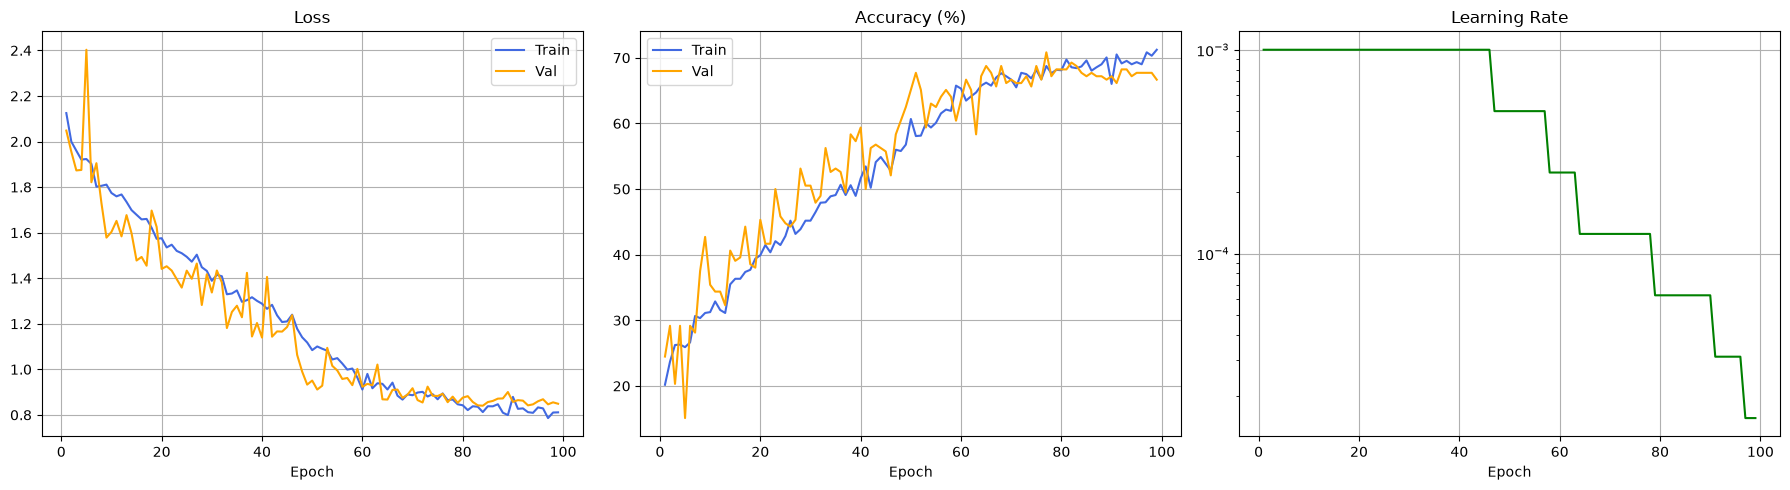

✓ Saved → result/training_performance_v2.png


In [21]:
epochs_range = range(1, len(history["train_loss"]) + 1)
fig, axes    = plt.subplots(1, 3, figsize=(18, 5))

# Loss
axes[0].plot(epochs_range, history["train_loss"], label="Train", color="royalblue")
axes[0].plot(epochs_range, history["val_loss"],   label="Val",   color="orange")
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch")
axes[0].legend(); axes[0].grid(True)

# Accuracy
axes[1].plot(epochs_range, [a*100 for a in history["train_acc"]], label="Train", color="royalblue")
axes[1].plot(epochs_range, [a*100 for a in history["val_acc"]],   label="Val",   color="orange")
axes[1].set_title("Accuracy (%)"); axes[1].set_xlabel("Epoch")
axes[1].legend(); axes[1].grid(True)

# Learning rate
axes[2].plot(epochs_range, history["lr"], color="green")
axes[2].set_title("Learning Rate"); axes[2].set_xlabel("Epoch")
axes[2].set_yscale("log"); axes[2].grid(True)

plt.tight_layout()
os.makedirs("result", exist_ok=True)
plt.savefig("result/training_performance_v2.png", dpi=150)
plt.show()
print("✓ Saved → result/training_performance_v2.png")